# Hourly Variability Sources — GEMS TCO  (2023 excluded)

**분석 목적**: hourly grouping (h0–h7) 했을 때 variability의 출처가 시간대별로 달라지는가?

| 분석 | 지표 | 질문 |
|------|------|------|
| **1** | γ_s(lag=1, h) — short-lag spatial semivariogram by hour | 소규모 공간 roughness가 시간대에 따라 달라지나? |
| **2** | σ_s²(h) — overall spatial variance by hour | 전체 공간 이질성이 시간대에 따라 달라지나? |
| **3** | 8×8 공분산 행렬 C[h₁,h₂] — day-to-day variability of spatial mean | 공간평균 자체가 시간대별로 얼마나 날마다 변하는가? |

**모델링 판단 기준**
- 1, 2가 시간대별로 **유의미하게 다르다** → 공간 구조가 diurnal cycle을 가짐  
  → `α(t) · [Z(x,t,d) − μ(x,t)]` 형태로 diurnal scaling 필요
- 1, 2가 시간대별로 **일정하다** → 공간 구조는 stationary, mean만 시간에 따라 변함  
  → `β(t,d) + ε(x,t,d)` 형태로 충분
- 3에서 C[h,h] 대각원소 차이가 크다 → spatial mean의 day-to-day 변동도 diurnal pattern을 가짐

**데이터**: GEMS TCO, 2022–2025, 4–9월, lat [−3, 2], lon [121, 131], 하루 8슬롯

In [1]:
import sys, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path

warnings.filterwarnings('ignore')

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed

YEARS         = ['2022', '2024', '2025']
MONTHS        = [4, 5, 6, 7, 8, 9]
LAT_RANGE     = [-3.0, 2.0]
LON_RANGE     = [121.0, 131.0]
MM_COND       = 10
SLOTS_PER_DAY = 8
N_SLOTS       = 8
MONTH_NAMES   = {4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep'}
SLOT_LABELS   = [f'h{h}' for h in range(N_SLOTS)]

# ── Shared color palettes (defined once, used everywhere) ─────────────────────
# Blues h0→h7 (slot colors)
blues = cm.Blues(np.linspace(0.30, 0.95, N_SLOTS))
# RdYlGn_r Apr→Sep (month colors)
month_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(MONTHS)))
MONTH_LABELS = [MONTH_NAMES[m] for m in MONTHS]   # ['Apr','May','Jun','Jul','Aug','Sep']

OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_variability_sources/")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Setup done.")

Setup done.


In [2]:
# ── Data loading ──────────────────────────────────────────────────────────────
# 처음 한 번만 계산 후 pkl 캐시 저장 → 이후 실행은 즉시 로드
#
# 로딩 시 NNS Map 생성은 data_loader 내부에서 불가피하게 발생하나,
# 캐시 후에는 건너뜀.
#
# 필요 컬럼: ColumnAmountO3, Hours_elapsed, Latitude, Longitude

CACHE_PATH = OUT_DIR / "df_spatial_stats_no2023_cache.pkl"

def slot_spatial_sem_lag1(df_slot):
    """
    γ_s(lag=1) in lat and lon directions for a single (day, slot) observation.
    Column names: 'Latitude', 'Longitude', 'ColumnAmountO3'
    """
    d = pd.DataFrame({
        'lat': pd.to_numeric(df_slot['Latitude'],       errors='coerce'),
        'lon': pd.to_numeric(df_slot['Longitude'],      errors='coerce'),
        'o3':  pd.to_numeric(df_slot['ColumnAmountO3'], errors='coerce'),
    }).dropna()
    if len(d) < 4:
        return np.nan, np.nan
    gammas_lat = []
    for _, grp in d.groupby('lon'):
        vals = grp.sort_values('lat')['o3'].values
        gammas_lat.extend([(vals[i+1] - vals[i])**2 / 2 for i in range(len(vals)-1)])
    gammas_lon = []
    for _, grp in d.groupby('lat'):
        vals = grp.sort_values('lon')['o3'].values
        gammas_lon.extend([(vals[i+1] - vals[i])**2 / 2 for i in range(len(vals)-1)])
    return (
        float(np.mean(gammas_lat)) if gammas_lat else np.nan,
        float(np.mean(gammas_lon)) if gammas_lon else np.nan,
    )


def load_spatial_stats():
    data_loader = load_data_dynamic_processed(config.mac_data_load_path)
    records = []
    for yr in YEARS:
        for mo in MONTHS:
            print(f"  Loading {yr}-{mo:02d}...", flush=True)
            df_map, _, _, _ = data_loader.load_maxmin_ordered_data_bymonthyear(
                lat_lon_resolution=[1, 1], mm_cond_number=MM_COND,
                years_=[yr], months_=[mo],
                lat_range=LAT_RANGE, lon_range=LON_RANGE,
                is_whittle=False)
            sorted_keys = sorted(df_map.keys())
            n_days = len(sorted_keys) // SLOTS_PER_DAY
            for d_idx in range(n_days):
                day_keys = sorted_keys[d_idx * SLOTS_PER_DAY:(d_idx + 1) * SLOTS_PER_DAY]
                for slot, key in enumerate(day_keys):
                    df_slot = df_map[key]
                    o3    = pd.to_numeric(df_slot['ColumnAmountO3'], errors='coerce').dropna()
                    hours = pd.to_numeric(df_slot['Hours_elapsed'],  errors='coerce').dropna()
                    if len(o3) == 0 or len(hours) == 0:
                        continue
                    g_lat, g_lon = slot_spatial_sem_lag1(df_slot)
                    records.append({
                        'year':          int(yr),
                        'month':         mo,
                        'day_idx':       d_idx,
                        'slot':          slot,
                        'hours_elapsed': float(hours.median()),
                        'spatial_mean':  float(o3.mean()),
                        'spatial_std':   float(o3.std()),
                        'sem_lat_lag1':  g_lat,
                        'sem_lon_lag1':  g_lon,
                        'n_obs':         int(len(o3)),
                    })
    df_out = pd.DataFrame(records).sort_values('hours_elapsed').reset_index(drop=True)
    df_out['spatial_mean_c'] = df_out.groupby(['year', 'month'])['spatial_mean'].transform(
        lambda x: x - x.mean())
    return df_out


def build_hourly_matrix(df):
    """Y (n_days × 8) — centered spatial means, for 8×8 cov matrix."""
    day_order = (df.groupby(['year', 'month', 'day_idx'])['hours_elapsed']
                   .min().reset_index().sort_values('hours_elapsed'))
    mat_rows, day_meta = [], []
    for _, row in day_order.iterrows():
        yr, mo, d_idx = int(row['year']), int(row['month']), int(row['day_idx'])
        sub = df[(df['year'] == yr) & (df['month'] == mo) & (df['day_idx'] == d_idx)]
        vec = np.full(SLOTS_PER_DAY, np.nan)
        for _, r in sub.iterrows():
            vec[int(r['slot'])] = r['spatial_mean_c']
        mat_rows.append(vec)
        day_meta.append((yr, mo, d_idx))
    return np.array(mat_rows), day_meta


# ── 캐시 로드 or 새로 계산 ─────────────────────────────────────────────────────
if CACHE_PATH.exists():
    print(f"Cache found — loading from {CACHE_PATH.name}")
    df = pd.read_pickle(CACHE_PATH)
    print(f"Loaded: {len(df)} rows")
else:
    print("No cache found. Computing (NNS Map 생성 포함, 약 10–15분)...")
    df = load_spatial_stats()
    df.to_pickle(CACHE_PATH)
    print(f"Saved cache → {CACHE_PATH}")

Y, day_meta = build_hourly_matrix(df)
n_days, n_slots = Y.shape
print(f"Y shape: {Y.shape},  NaN: {np.isnan(Y).mean()*100:.1f}%")

No cache found. Computing (NNS Map 생성 포함, 약 10–15분)...
  Loading 2022-04...
--- Global Monthly Mean for 2022-4: 235.4573 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2022-05...
--- Global Monthly Mean for 2022-5: 242.8715 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2022-06...
--- Global Monthly Mean for 2022-6: 246.6272 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2022-07...
--- Global Monthly Mean for 2022-7: 250.6500 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2022-08...
--- Global Monthly Mean for 2022-8: 257.3822 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2022-09...
--- Global Monthly Mean for 2022-9: 263.5558 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2024-04...
--- Global Monthly Mean for 2024-4: 243.9092 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  Loading 2024-05...
--- Global Monthly Mean for 2024-5:

---
## Analysis 1 — Short-Lag Spatial Semivariogram by Hour

$$\hat{\gamma}_s(\text{lag=1},\, h) = \frac{1}{2|P_h|} \sum_{\text{days}\,d} \sum_{(i,j)\in P} \left[Z(s_i, h, d) - Z(s_j, h, d)\right]^2$$

- $P_h$: 시간대 $h$의 **모든 날**에 걸쳐 pooled된 nearest-neighbor pair 집합
- 같은 시간대의 여러 날 데이터를 합쳐서 추정 → 추정 안정성 확보
- **이 값이 시간대별로 다르면** 소규모 공간 roughness가 diurnal cycle을 가짐

In [3]:
# ── Analysis 1: Short-lag spatial semivariogram (pooled across days, by hour) ─
# 방법 A: 기존 pre-computed pkl (더 정밀, lag 1-3 포함)

PKL_PATH = (Path(config.mac_save_computed_semi_path) /
            "diurnal_slot_sem_22_23_24_25_m04_m05_m06_m07_m08_m09.pkl")
with open(PKL_PATH, "rb") as f:
    sem_data = pickle.load(f)

lags_lat = [d[0] for d in sem_data["lags_lat"]]
lags_lon = [d[1] for d in sem_data["lags_lon"]]
lat_sem  = sem_data["lat"]    # {slot: [γ_lag1, γ_lag2, γ_lag3]}
lon_sem  = sem_data["lon"]
meta     = sem_data["meta"]

# 방법 B: raw data에서 계산한 lag-1 (monthly breakdown에도 사용)
# df['sem_lat_lag1'] — slot_spatial_sem_lag1()로 per-observation 계산됨
an1_pooled_lat = df.groupby('slot')['sem_lat_lag1'].mean().values   # shape (8,)
an1_pooled_lon = df.groupby('slot')['sem_lon_lag1'].mean().values

print(f"Pooled γ_s(lag=1) by slot:")
print(f"{'slot':>5} | {'lat (pkl)':>10} | {'lon (pkl)':>10} | {'lat (raw)':>10} | {'lon (raw)':>10}")
for h in range(N_SLOTS):
    print(f"  h{h}   | {lat_sem[h][0]:>10.4f} | {lon_sem[h][0]:>10.4f} "
          f"| {an1_pooled_lat[h]:>10.4f} | {an1_pooled_lon[h]:>10.4f}")

Pooled γ_s(lag=1) by slot:
 slot |  lat (pkl) |  lon (pkl) |  lat (raw) |  lon (raw)
  h0   |     3.9022 |     3.9926 |     4.1508 |     4.2540
  h1   |     4.1992 |     4.3310 |     4.4586 |     4.5866
  h2   |     4.1620 |     4.3650 |     4.4117 |     4.6128
  h3   |     4.1183 |     4.4142 |     4.3468 |     4.6465
  h4   |     4.3781 |     4.8007 |     4.4369 |     4.8307
  h5   |     4.1741 |     4.5942 |     4.3767 |     4.8316
  h6   |     3.4840 |     3.8748 |     3.6512 |     4.1091
  h7   |     3.0770 |     3.3647 |     3.3419 |     3.6805


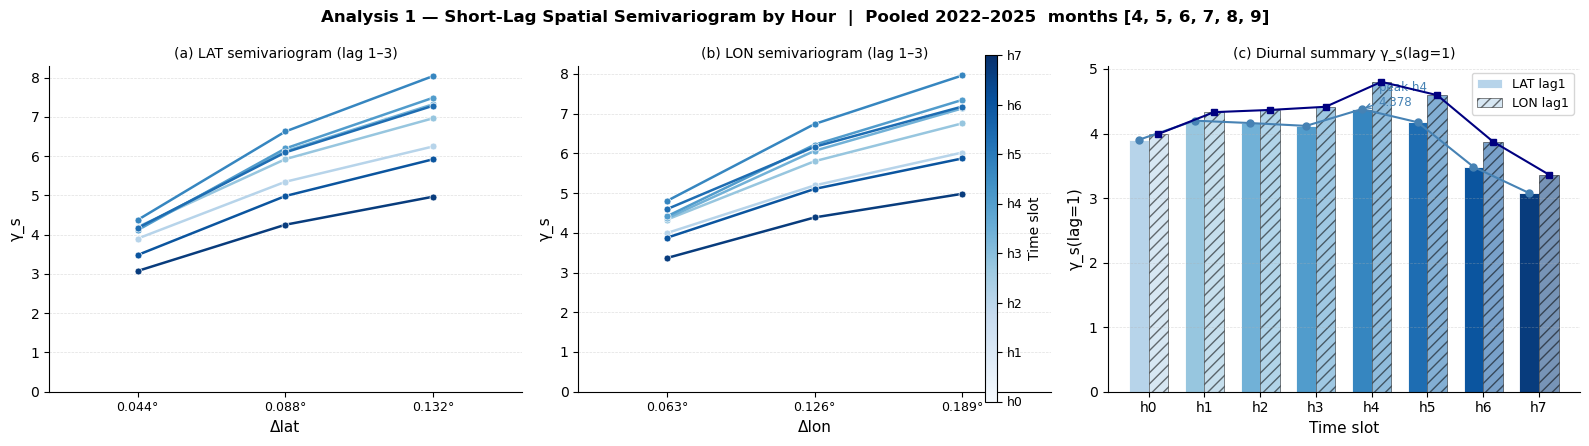

In [4]:
# ── Analysis 1 시각화 ─────────────────────────────────────────────────────────

blues = cm.Blues(np.linspace(0.30, 0.95, N_SLOTS))
x = np.arange(N_SLOTS)
slot_labels = [f'h{h}' for h in range(N_SLOTS)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(
    f'Analysis 1 — Short-Lag Spatial Semivariogram by Hour  |  '
    f'Pooled {"–".join([YEARS[0], YEARS[-1]])}  months {MONTHS}',
    fontsize=12, fontweight='bold'
)

# (a) γ_s(lag=1,2,3) curves per slot — lat
ax = axes[0]
for h in range(N_SLOTS):
    ax.plot(lags_lat, lat_sem[h], 'o-', color=blues[h], lw=1.8, ms=5,
            markeredgecolor='white', markeredgewidth=0.5, zorder=3)
x_pad = lags_lat[0] * 0.6
ax.set_xlim(lags_lat[0] - x_pad, lags_lat[-1] + x_pad)
ax.set_xticks(lags_lat)
ax.set_xticklabels([f'{d:.3f}°' for d in lags_lat], fontsize=9)
ax.set_xlabel('Δlat', fontsize=11); ax.set_ylabel('γ_s', fontsize=11)
ax.set_title('(a) LAT semivariogram (lag 1–3)', fontsize=10)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# (b) γ_s(lag=1,2,3) curves per slot — lon
ax = axes[1]
for h in range(N_SLOTS):
    ax.plot(lags_lon, lon_sem[h], 'o-', color=blues[h], lw=1.8, ms=5,
            markeredgecolor='white', markeredgewidth=0.5, zorder=3)
x_pad = lags_lon[0] * 0.6
ax.set_xlim(lags_lon[0] - x_pad, lags_lon[-1] + x_pad)
ax.set_xticks(lags_lon)
ax.set_xticklabels([f'{d:.3f}°' for d in lags_lon], fontsize=9)
ax.set_xlabel('Δlon', fontsize=11); ax.set_ylabel('γ_s', fontsize=11)
ax.set_title('(b) LON semivariogram (lag 1–3)', fontsize=10)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# (c) γ_s(lag=1) bar — diurnal summary
ax = axes[2]
w = 0.35
lat_lag1 = [lat_sem[h][0] for h in range(N_SLOTS)]
lon_lag1 = [lon_sem[h][0] for h in range(N_SLOTS)]
ax.bar(x - w/2, lat_lag1, width=w, color=[blues[h] for h in range(N_SLOTS)],
       edgecolor='white', lw=0.6, label='LAT lag1')
ax.bar(x + w/2, lon_lag1, width=w, color=[blues[h] for h in range(N_SLOTS)],
       edgecolor='black', lw=0.6, alpha=0.55, hatch='///', label='LON lag1')
ax.plot(x - w/2, lat_lag1, 'o-', color='steelblue', lw=1.5, ms=5, zorder=5)
ax.plot(x + w/2, lon_lag1, 's-', color='navy',      lw=1.5, ms=5, zorder=5)
peak_h = int(np.argmax(lat_lag1))
ax.annotate(f'peak h{peak_h}\n{lat_lag1[peak_h]:.3f}',
            xy=(peak_h - w/2, lat_lag1[peak_h]),
            xytext=(peak_h - w/2 + 0.3, lat_lag1[peak_h] + 0.05),
            fontsize=8.5, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.0))
ax.set_xticks(x); ax.set_xticklabels(slot_labels, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('γ_s(lag=1)', fontsize=11)
ax.set_title('(c) Diurnal summary γ_s(lag=1)', fontsize=10)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=9)

# Colorbar (h0→h7)
norm = mcolors.Normalize(vmin=0, vmax=N_SLOTS-1)
sm   = cm.ScalarMappable(cmap=cm.Blues, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:2], orientation='vertical',
                    fraction=0.015, pad=0.02, aspect=30)
cbar.set_ticks(np.arange(N_SLOTS))
cbar.set_ticklabels(slot_labels, fontsize=9)
cbar.set_label('Time slot', fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / 'an1_spatial_sem_by_hour_no2023.png', dpi=150, bbox_inches='tight')
plt.show()

slot     h0     h1     h2     h3     h4     h5     h6     h7
Apr   5.009  4.917  4.687  4.551  4.789  5.243  4.372  3.980
May   4.002  4.581  4.645  4.549  4.680  4.426  3.751  3.075
Jun   3.606  4.283  4.511  4.501  4.433  3.986  3.357  2.689
Jul   3.351  3.834  3.916  3.939  3.920  3.745  3.096  2.795
Aug   3.926  4.077  4.012  3.821  3.686  3.654  3.359  3.743
Sep   5.034  5.074  4.707  4.730  5.129  5.229  3.983  3.782
All   4.151  4.459  4.412  4.347  4.437  4.377  3.651  3.342


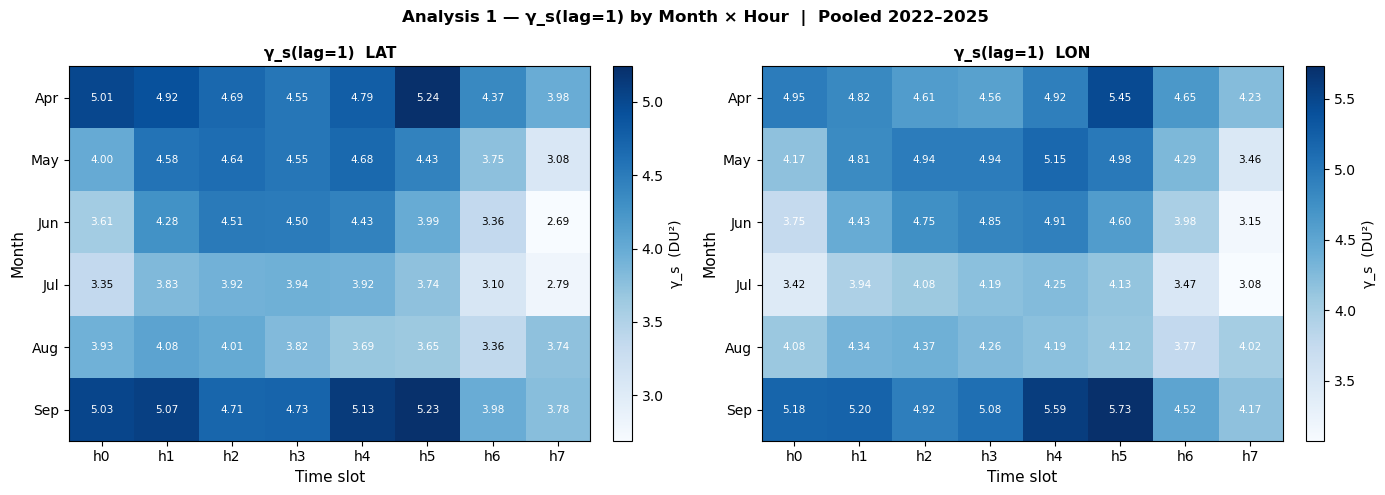

In [5]:
# ── Analysis 1: Monthly × hour heatmap of γ_s(lag=1) ─────────────────────────

an1_monthly_lat = (
    df.groupby(["month", "slot"])["sem_lat_lag1"].mean()
      .unstack("slot").rename(columns=lambda h: f"h{int(h)}")
      .reindex(MONTHS)
)
an1_monthly_lat.index = [MONTH_NAMES[m] for m in an1_monthly_lat.index]

an1_monthly_lon = (
    df.groupby(["month", "slot"])["sem_lon_lag1"].mean()
      .unstack("slot").rename(columns=lambda h: f"h{int(h)}")
      .reindex(MONTHS)
)
an1_monthly_lon.index = [MONTH_NAMES[m] for m in an1_monthly_lon.index]

# ── Overall (all months pooled) row 추가 ──────────────────────────────────────
_all_lat = df.groupby("slot")["sem_lat_lag1"].mean().rename(lambda h: f"h{int(h)}")
_all_lon = df.groupby("slot")["sem_lon_lag1"].mean().rename(lambda h: f"h{int(h)}")
an1_monthly_lat = pd.concat([an1_monthly_lat,
                              pd.DataFrame([_all_lat.values], index=["All"], columns=_all_lat.index)])
an1_monthly_lon = pd.concat([an1_monthly_lon,
                              pd.DataFrame([_all_lon.values], index=["All"], columns=_all_lon.index)])

# ── Rows for heatmap: months only (no All row) + display ─────────────────────
an1_heatmap_lat = an1_monthly_lat.drop(index="All")
an1_heatmap_lon = an1_monthly_lon.drop(index="All")

print(an1_monthly_lat.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Analysis 1 — γ_s(lag=1) by Month × Hour  |  '
    f'Pooled {YEARS[0]}–{YEARS[-1]}',
    fontsize=12, fontweight='bold'
)

for ax, mat, direction in [(axes[0], an1_heatmap_lat, 'LAT'), (axes[1], an1_heatmap_lon, 'LON')]:
    vals = mat.values.astype(float)
    im = ax.imshow(vals, cmap='Blues', aspect='auto')
    ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels([f'h{h}' for h in range(N_SLOTS)])
    ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
    ax.set_xlabel('Time slot', fontsize=11); ax.set_ylabel('Month', fontsize=11)
    ax.set_title(f'γ_s(lag=1)  {direction}', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='γ_s  (DU²)')
    vmax = np.nanmax(vals)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if np.isfinite(vals[i, j]):
                ax.text(j, i, f'{vals[i,j]:.2f}', ha='center', va='center', fontsize=7.5,
                        color='white' if vals[i, j] > vmax * 0.65 else 'black')

plt.tight_layout()
plt.savefig(OUT_DIR / 'an1_spatial_sem_monthly_heatmap_no2023.png', dpi=150, bbox_inches='tight')
plt.show()

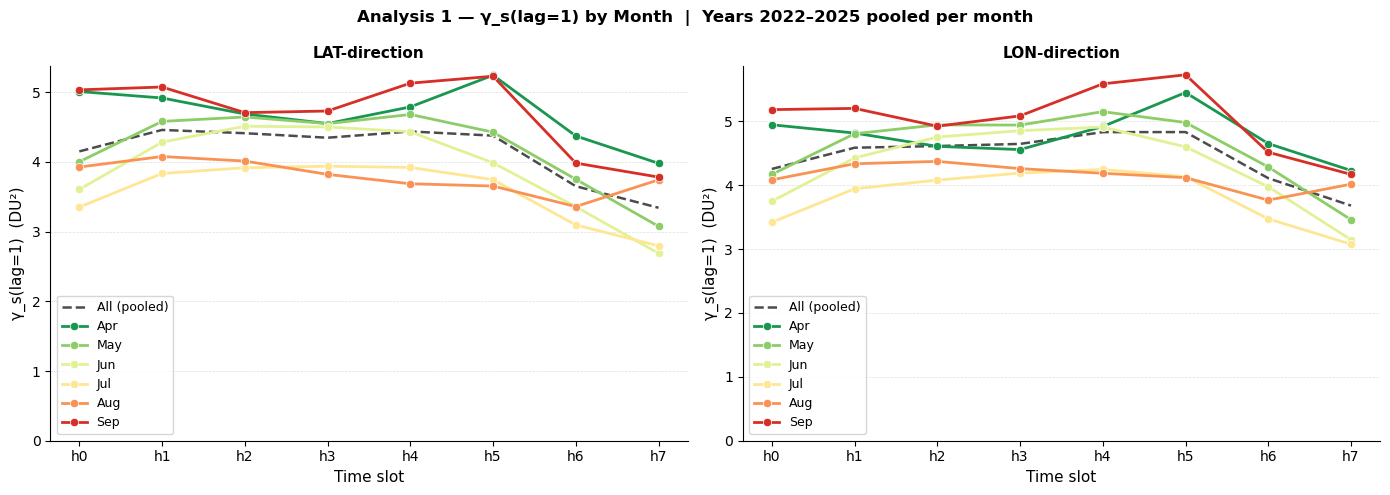

Saved: an1_spatial_sem_monthly_lines_no2023.png


In [6]:
# ── Analysis 1: Monthly line plot — γ_s(lag=1) ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Analysis 1 — γ_s(lag=1) by Month  |  '
    f'Years {YEARS[0]}–{YEARS[-1]} pooled per month',
    fontsize=12, fontweight='bold'
)

for ax, monthly_df, direction in [
    (axes[0], an1_monthly_lat, 'LAT'),
    (axes[1], an1_monthly_lon, 'LON'),
]:
    # All-months pooled: 굵은 검정 점선 배경 기준선 (zorder=1)
    all_row = monthly_df.loc['All'].values.astype(float)
    ax.plot(range(N_SLOTS), all_row, 'k--',
            lw=1.8, alpha=0.7,
            label='All (pooled)', zorder=2)

    # Monthly lines: 전경 (zorder=5+)
    for i, mo in enumerate(MONTHS):
        mname = MONTH_NAMES[mo]
        row = monthly_df.loc[mname].values.astype(float)
        ax.plot(range(N_SLOTS), row, 'o-',
                color=month_colors[i], lw=2.0, ms=6,
                markeredgecolor='white', markeredgewidth=0.5,
                label=mname, zorder=5 + i)

    ax.set_xticks(range(N_SLOTS))
    ax.set_xticklabels(SLOT_LABELS, fontsize=10)
    ax.set_xlabel('Time slot', fontsize=11)
    ax.set_ylabel('γ_s(lag=1)  (DU²)', fontsize=11)
    ax.set_title(f'{direction}-direction', fontsize=11, fontweight='bold')
    ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.8, loc='best')

plt.tight_layout()
plt.savefig(OUT_DIR / 'an1_spatial_sem_monthly_lines_no2023.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: an1_spatial_sem_monthly_lines_no2023.png")

---
## Analysis 2 — Overall Spatial Variance by Hour

$$\hat{\sigma}_s^2(h) = \frac{\sum_d (n_d - 1)\,\text{Var}_x\left[Z(x,\,h,\,d)\right]}{\sum_d n_d - 1}$$

- 날별 within-day 공간분산을 **sample size로 가중평균** (단순 평균보다 정확)
- between-day 항 $\sum_d n_d(\bar{\mu}_d - \bar{\mu})^2$ 제외 — 이건 Analysis 3 C[h,h]에서 따로 봄
- γ_s(lag=1)은 **소규모(고주파)** 공간 변동, σ_s²는 **전체(저+고주파)** 공간 변동
- 두 값이 같이 변하면 전체 공간 구조가 diurnal cycle / 따로 변하면 scale 분리 필요

In [7]:
# ── Analysis 2: Overall spatial variance by hour ──────────────────────────────
# Pooled variance: 날 단위 평균이 아니라 모든 날 pooling 후 분산 계산
# pooled_var(h) = [Σ_d (n_d-1)σ²_d + Σ_d n_d(μ_d-μ̄)²] / (Σ_d n_d - 1)

def pooled_var_by_group(grp):
    """Within-day spatial variance, pooled across days (sample-size weighted).
    Between-day term excluded — kept separate in Analysis 3.
    """
    n    = grp['n_obs'].values.astype(float)
    sig2 = grp['spatial_std'].values.astype(float) ** 2
    N    = n.sum()
    return ((n - 1) * sig2).sum() / (N - len(n))

# Pooled all months
an2_pooled = (
    df.groupby('slot').apply(pooled_var_by_group)
      .rename(lambda h: f'h{int(h)}')
      .values   # shape (8,)
)

# Monthly (pooled within each month across all years)
an2_monthly_rows = {}
for mo in MONTHS:
    sub = df[df['month'] == mo]
    an2_monthly_rows[MONTH_NAMES[mo]] = (
        sub.groupby('slot').apply(pooled_var_by_group)
           .rename(lambda h: f'h{int(h)}')
    )
an2_monthly = pd.DataFrame(an2_monthly_rows).T
an2_monthly.columns = [f'h{int(c)}' if not str(c).startswith('h') else c
                       for c in an2_monthly.columns]

# Add All row
_all_row = pd.DataFrame([an2_pooled], index=['All'],
                        columns=[f'h{h}' for h in range(N_SLOTS)])
an2_monthly = pd.concat([an2_monthly, _all_row])

print("Pooled σ²(h) by slot (all months):")
for h in range(N_SLOTS):
    print(f"  h{h}: {an2_pooled[h]:.4f}")
print()
print(an2_monthly.round(2).to_string())

Pooled σ²(h) by slot (all months):
  h0: 19.3868
  h1: 20.4690
  h2: 20.3091
  h3: 19.8349
  h4: 19.6142
  h5: 18.5394
  h6: 15.8417
  h7: 13.4009

        h0     h1     h2     h3     h4     h5     h6     h7
Apr  36.04  37.26  33.05  28.47  26.20  22.83  18.60  13.88
May  16.42  17.78  18.82  19.01  19.68  18.76  16.69  12.94
Jun  15.88  17.02  18.05  18.83  18.83  18.21  15.87  12.21
Jul  15.26  16.56  17.27  17.94  18.04  17.51  15.19  12.97
Aug  15.92  17.14  17.73  17.32  16.35  15.93  14.00  15.58
Sep  16.93  17.14  16.87  17.39  18.59  18.01  14.69  12.83
All  19.39  20.47  20.31  19.83  19.61  18.54  15.84  13.40


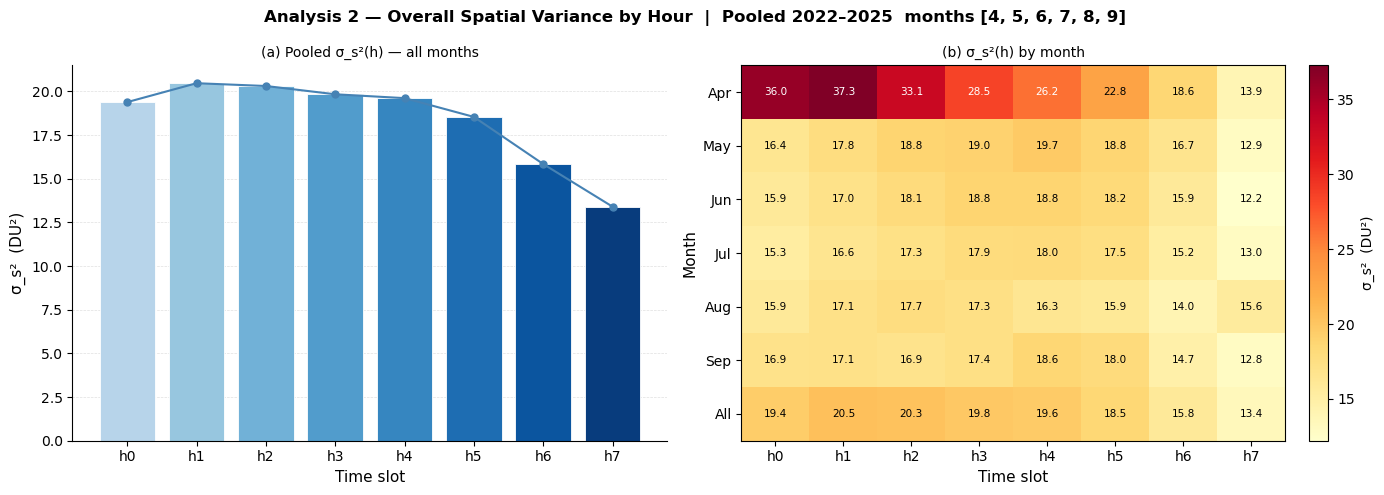

In [8]:
# ── Analysis 2 시각화 — pooled diurnal + monthly heatmap ─────────────────────

month_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(MONTHS)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Analysis 2 — Overall Spatial Variance by Hour  |  '
    f'Pooled {YEARS[0]}–{YEARS[-1]}  months {MONTHS}',
    fontsize=12, fontweight='bold'
)

# (a) Pooled σ_s²(h) bar
ax = axes[0]
ax.bar(range(N_SLOTS), an2_pooled, color=[blues[h] for h in range(N_SLOTS)],
       edgecolor='white', lw=0.6)
ax.plot(range(N_SLOTS), an2_pooled, 'o-', color='steelblue', lw=1.5, ms=5, zorder=5)
ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels([f'h{h}' for h in range(N_SLOTS)], fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('σ_s²  (DU²)', fontsize=11)
ax.set_title('(a) Pooled σ_s²(h) — all months', fontsize=10)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# (b) Monthly heatmap
ax = axes[1]
vals = an2_monthly.values.astype(float)
im = ax.imshow(vals, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels([f'h{h}' for h in range(N_SLOTS)])
ax.set_yticks(range(len(an2_monthly.index))); ax.set_yticklabels(an2_monthly.index)
ax.set_xlabel('Time slot', fontsize=11); ax.set_ylabel('Month', fontsize=11)
ax.set_title('(b) σ_s²(h) by month', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='σ_s²  (DU²)')
vmax = np.nanmax(vals)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        if np.isfinite(vals[i, j]):
            ax.text(j, i, f'{vals[i,j]:.1f}', ha='center', va='center', fontsize=7.5,
                    color='white' if vals[i, j] > vmax * 0.65 else 'black')

plt.tight_layout()
plt.savefig(OUT_DIR / 'an2_spatial_var_by_hour_no2023.png', dpi=150, bbox_inches='tight')
plt.show()

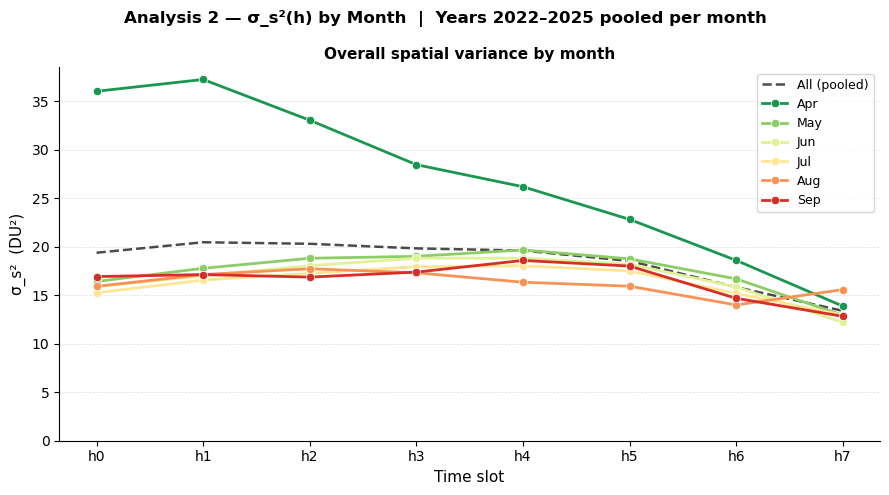

Saved: an2_spatial_var_monthly_lines_no2023.png


In [9]:
# ── Analysis 2: Monthly line plot — σ_s²(h) ─────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    f'Analysis 2 — σ_s²(h) by Month  |  '
    f'Years {YEARS[0]}–{YEARS[-1]} pooled per month',
    fontsize=12, fontweight='bold'
)

# All-months pooled: 굵은 검정 점선 기준선 (zorder=2)
all_row = an2_monthly.loc['All'].values.astype(float)
ax.plot(range(N_SLOTS), all_row, 'k--',
        lw=1.8, alpha=0.7,
        label='All (pooled)', zorder=2)

# Monthly lines: 전경 (zorder=5+)
for i, mo in enumerate(MONTHS):
    mname = MONTH_NAMES[mo]
    row = an2_monthly.loc[mname].values.astype(float)
    ax.plot(range(N_SLOTS), row, 'o-',
            color=month_colors[i], lw=2.0, ms=6,
            markeredgecolor='white', markeredgewidth=0.5,
            label=mname, zorder=5 + i)

ax.set_xticks(range(N_SLOTS))
ax.set_xticklabels(SLOT_LABELS, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('σ_s²  (DU²)', fontsize=11)
ax.set_title('Overall spatial variance by month', fontsize=11, fontweight='bold')
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, framealpha=0.8, loc='best')

plt.tight_layout()
plt.savefig(OUT_DIR / 'an2_spatial_var_monthly_lines_no2023.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: an2_spatial_var_monthly_lines_no2023.png")

## Analysis 2 — April year-by-year breakdown

April has the highest σ². Is it driven by a specific year?

April σ²(h) by year:
              h0     h1     h2     h3     h4     h5     h6     h7
2022       11.67  12.87  13.95  14.25  14.90  14.23  12.10   8.73
2024       79.28  79.74  64.82  50.80  42.52  34.75  27.04  21.17
2025       16.99  18.50  20.14  20.25  21.02  19.40  16.71  11.80
Apr (all)  36.04  37.26  33.05  28.47  26.20  22.83  18.60  13.88


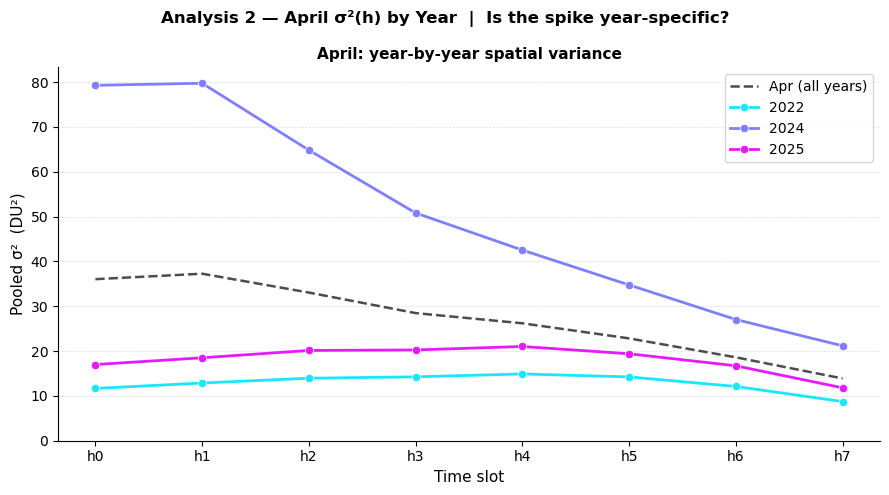

Saved → /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_variability_sources/an2_april_yearly_no2023.png


In [10]:
# ── April: year-by-year pooled variance per slot ─────────────────────────────

apr = df[df['month'] == 4]

apr_yearly = {}
for yr in [int(y) for y in YEARS]:
    sub = apr[apr['year'] == yr]
    apr_yearly[str(yr)] = (
        sub.groupby('slot').apply(pooled_var_by_group)
           .rename(lambda h: f'h{int(h)}')
    )
apr_yearly_df = pd.DataFrame(apr_yearly).T
apr_yearly_df.columns = [f'h{h}' for h in range(N_SLOTS)]

# Add Apr-all row (4 years pooled)
apr_all = pd.Series(
    apr.groupby('slot').apply(pooled_var_by_group).rename(lambda h: f'h{int(h)}').values,
    index=[f'h{h}' for h in range(N_SLOTS)], name='Apr (all)'
)
apr_yearly_df = pd.concat([apr_yearly_df,
                            apr_all.to_frame().T])

print("April σ²(h) by year:")
print(apr_yearly_df.round(2).to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
year_colors = plt.cm.cool(np.linspace(0.1, 0.9, len(YEARS)))

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    'Analysis 2 — April σ²(h) by Year  |  Is the spike year-specific?',
    fontsize=12, fontweight='bold'
)

# All-years pooled April: 검정 점선 기준선
ax.plot(range(N_SLOTS), apr_all.values.astype(float),
        'k--', lw=1.8, alpha=0.7, label='Apr (all years)', zorder=2)

for i, yr in enumerate(YEARS):
    row = apr_yearly_df.loc[yr].values.astype(float)
    ax.plot(range(N_SLOTS), row, 'o-',
            color=year_colors[i], lw=2.0, ms=6,
            markeredgecolor='white', markeredgewidth=0.5,
            label=yr, zorder=5 + i)

ax.set_xticks(range(N_SLOTS))
ax.set_xticklabels(SLOT_LABELS, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('Pooled σ²  (DU²)', fontsize=11)
ax.set_title('April: year-by-year spatial variance', fontsize=11, fontweight='bold')
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, framealpha=0.8, loc='best')

plt.tight_layout()
plt.savefig(OUT_DIR / 'an2_april_yearly_no2023.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR / 'an2_april_yearly_no2023.png'}")

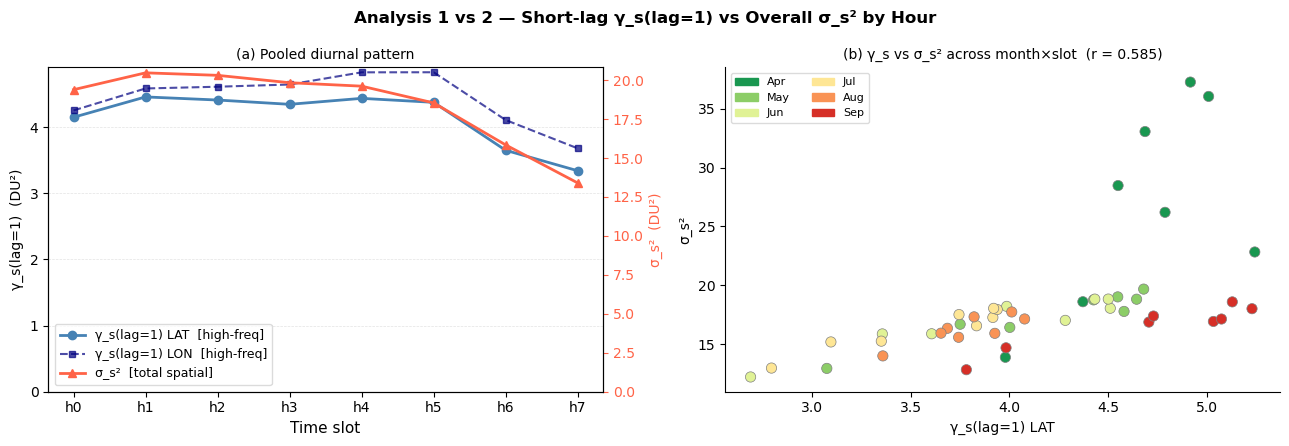

γ_s vs σ_s² correlation (month×slot pooled): r = 0.585


In [11]:
# ── Analysis 1 vs 2 비교 — 고주파 vs 전체 공간 variability ───────────────────
# 두 값이 같이 변하는지, 아니면 패턴이 다른지 확인

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(
    'Analysis 1 vs 2 — Short-lag γ_s(lag=1) vs Overall σ_s² by Hour',
    fontsize=12, fontweight='bold'
)

# (a) Line comparison (pooled)
ax = axes[0]
ax2 = ax.twinx()
l1, = ax.plot(range(N_SLOTS),  an1_pooled_lat, 'o-', color='steelblue', lw=2, ms=6,
              label='γ_s(lag=1) LAT  [high-freq]')
l2, = ax.plot(range(N_SLOTS),  an1_pooled_lon, 's--', color='navy', lw=1.5, ms=5,
              label='γ_s(lag=1) LON  [high-freq]', alpha=0.7)
l3, = ax2.plot(range(N_SLOTS), an2_pooled, '^-', color='tomato', lw=2, ms=6,
               label='σ_s²  [total spatial]')
ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels([f'h{h}' for h in range(N_SLOTS)])
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('γ_s(lag=1)  (DU²)', fontsize=10)
ax2.set_ylabel('σ_s²  (DU²)', fontsize=10, color='tomato')
ax2.tick_params(axis='y', colors='tomato')
ax.set_title('(a) Pooled diurnal pattern', fontsize=10)
ax.set_ylim(bottom=0); ax2.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.35); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.legend(handles=[l1, l2, l3], fontsize=9, framealpha=0.7)

# (b) Correlation scatter: does γ_s ∝ σ_s² across month×slot?
ax = axes[1]
x_vals = an1_monthly_lat.drop(index='All').values.flatten()
y_vals = an2_monthly.drop(index='All').values.flatten()
mask   = np.isfinite(x_vals) & np.isfinite(y_vals)
colors_flat = [month_colors[i] for i in range(len(MONTHS))
               for _ in range(N_SLOTS)]
ax.scatter(x_vals[mask], y_vals[mask], c=[colors_flat[i] for i in np.where(mask)[0]],
           s=55, edgecolors='gray', linewidths=0.5, zorder=4)
# Correlation
r = np.corrcoef(x_vals[mask], y_vals[mask])[0, 1]
ax.set_xlabel('γ_s(lag=1) LAT', fontsize=10)
ax.set_ylabel('σ_s²', fontsize=10)
ax.set_title(f'(b) γ_s vs σ_s² across month×slot  (r = {r:.3f})', fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
# Legend for months
from matplotlib.patches import Patch
handles = [Patch(color=month_colors[i], label=list(MONTH_NAMES.values())[i]) for i in range(len(MONTHS))]
ax.legend(handles=handles, fontsize=8, framealpha=0.7, ncol=2)

plt.tight_layout()
plt.savefig(OUT_DIR / 'an1_an2_comparison_no2023.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"γ_s vs σ_s² correlation (month×slot pooled): r = {r:.3f}")

---
## Analysis 3 — 8×8 Covariance Matrix: Day-to-Day Variability of Spatial Mean

$$\hat{C}[h_1, h_2] = \frac{1}{n} \sum_{d=1}^{n} \bar{Y}[d, h_1] \cdot \bar{Y}[d, h_2]$$

- $\bar{Y}[d, h]$: $d$번째 날 $h$번째 슬롯의 **공간평균** (year-month 내 centered)
- **대각원소 $\hat{C}[h,h]$**: 시간대 $h$에서 공간평균의 day-to-day 분산
- Analysis 1, 2와 달리 **시간(날짜) 방향** variability → α(t) 필요 여부와 직접 연관

> Analysis 1, 2가 diurnal pattern을 보인다면:  
> `Z(x,t,d) = μ(x,t) + α(t)·η(x,d) + ε(x,t,d)` 형태 검토  
> Analysis 3에서 `C[h,h]`가 시간대별로 다르면 `α(t)` 자체가 diurnal scaling을 가짐

In [12]:
# ── Analysis 3: 8×8 공분산 행렬 ──────────────────────────────────────────────

def sample_cov_matrix(Y):
    n_s = Y.shape[1]
    C = np.full((n_s, n_s), np.nan)
    for h1 in range(n_s):
        for h2 in range(n_s):
            mask = np.isfinite(Y[:, h1]) & np.isfinite(Y[:, h2])
            if mask.sum() > 1:
                C[h1, h2] = np.mean(Y[mask, h1] * Y[mask, h2])
    return C


def toeplitz_check(C):
    n = C.shape[0]
    rows = []
    for k in range(n):
        diag_vals = np.array([C[h, h+k] for h in range(n-k) if np.isfinite(C[h, h+k])])
        if len(diag_vals) == 0:
            continue
        mean_val, std_val = diag_vals.mean(), diag_vals.std()
        cv = std_val / abs(mean_val) if abs(mean_val) > 1e-10 else np.nan
        rows.append({'lag_k': k, 'n_elems': len(diag_vals),
                     'mean': round(mean_val, 4), 'std': round(std_val, 4),
                     'CV=std/|mean|': round(cv, 4) if np.isfinite(cv) else np.nan,
                     'values': np.round(diag_vals, 4).tolist()})
    return pd.DataFrame(rows)


C = sample_cov_matrix(Y)
df_toep = toeplitz_check(C)

# ── 데이터 범위 명시 ───────────────────────────────────────────────────────────
print(f"Data: years {YEARS},  months {MONTHS}  (all pooled)")
print(f"n_days = {n_days},  slots_per_day = {n_slots}")
print()
print("8×8 표본 공분산 행렬 C:")
print(pd.DataFrame(C, columns=SLOT_LABELS, index=SLOT_LABELS).round(4).to_string())
print("\nToeplitz 체크:")
print(df_toep[['lag_k','n_elems','mean','std','CV=std/|mean|']].to_string(index=False))

Data: years ['2022', '2024', '2025'],  months [4, 5, 6, 7, 8, 9]  (all pooled)
n_days = 543,  slots_per_day = 8

8×8 표본 공분산 행렬 C:
        h0      h1      h2      h3      h4      h5      h6       h7
h0  9.0041  8.8934  8.6444  8.2574  8.0821  7.9862  7.5145   7.3466
h1  8.8934  9.1807  9.1609  8.8485  8.6036  8.2600  7.5677   6.7743
h2  8.6444  9.1609  9.4432  9.2867  9.0121  8.4419  7.5708   6.1949
h3  8.2574  8.8485  9.2867  9.3695  9.0451  8.4390  7.5534   5.9886
h4  8.0821  8.6036  9.0121  9.0451  9.3026  8.6589  8.0586   6.6466
h5  7.9862  8.2600  8.4419  8.4390  8.6589  8.7890  8.3880   7.7752
h6  7.5145  7.5677  7.5708  7.5534  8.0586  8.3880  8.7254   8.6034
h7  7.3466  6.7743  6.1949  5.9886  6.6466  7.7752  8.6034  12.1299

Toeplitz 체크:
 lag_k  n_elems   mean    std  CV=std/|mean|
     0        8 9.4930 1.0264         0.1081
     1        7 8.8624 0.3017         0.0340
     2        6 8.4630 0.4321         0.0511
     3        5 7.9006 0.7222         0.0914
     4        4 7.4

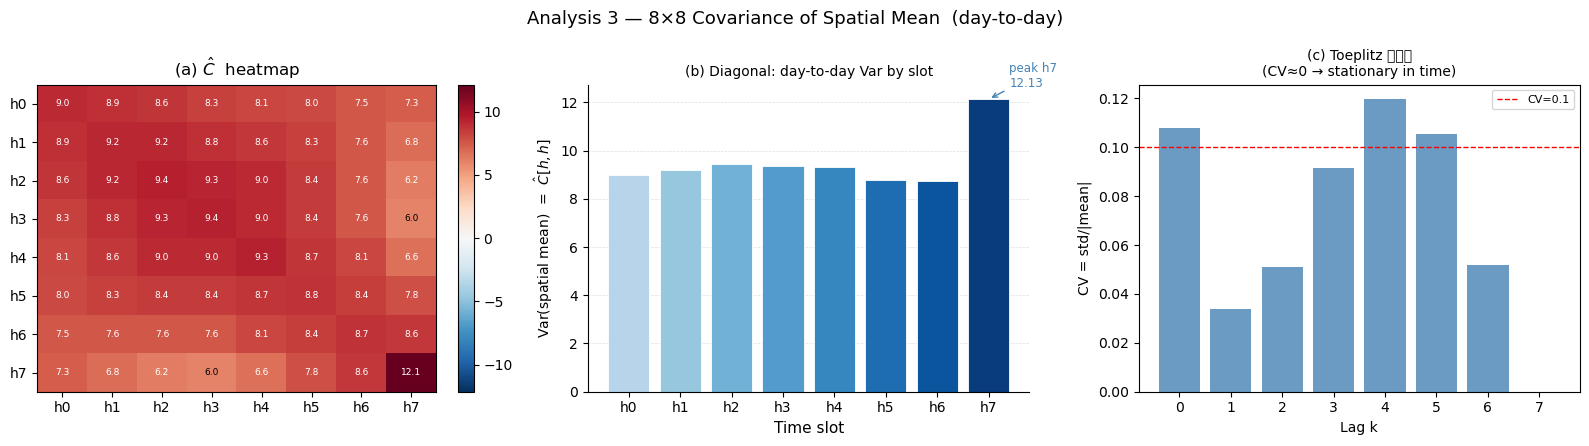

In [13]:
# ── Analysis 3 시각화 ─────────────────────────────────────────────────────────

diag_var = np.array([C[h, h] for h in range(N_SLOTS)])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Analysis 3 — 8×8 Covariance of Spatial Mean  (day-to-day)', fontsize=13)

# (a) Heatmap
ax = axes[0]
vmax = np.nanmax(np.abs(C))
im = ax.imshow(C, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
slot_labels = [f'h{i}' for i in range(8)]
ax.set_xticks(range(8)); ax.set_xticklabels(slot_labels)
ax.set_yticks(range(8)); ax.set_yticklabels(slot_labels)
ax.set_title('(a) $\\hat{C}$  heatmap')
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(8):
    for j in range(8):
        if np.isfinite(C[i, j]):
            ax.text(j, i, f'{C[i,j]:.1f}', ha='center', va='center', fontsize=6.5,
                    color='white' if abs(C[i,j]) > vmax*0.5 else 'black')

# (b) Diagonal: Var(spatial mean) by slot
ax = axes[1]
ax.bar(range(N_SLOTS), diag_var, color=[blues[h] for h in range(N_SLOTS)],
       edgecolor='white', lw=0.6)
ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(slot_labels)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('Var(spatial mean)  =  $\\hat{C}[h,h]$', fontsize=10)
ax.set_title('(b) Diagonal: day-to-day Var by slot', fontsize=10)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
peak_h = int(np.argmax(diag_var))
ax.annotate(f'peak h{peak_h}\n{diag_var[peak_h]:.2f}',
            xy=(peak_h, diag_var[peak_h]),
            xytext=(peak_h + 0.4, diag_var[peak_h] + 0.5),
            fontsize=8.5, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.0))

# (c) Toeplitz CV
ax = axes[2]
ax.bar(df_toep['lag_k'], df_toep['CV=std/|mean|'], color='steelblue', alpha=0.8)
ax.axhline(0.1, ls='--', color='red', lw=1, label='CV=0.1')
ax.set_xlabel('Lag k'); ax.set_ylabel('CV = std/|mean|')
ax.set_title('(c) Toeplitz 이탈도\n(CV≈0 → stationary in time)', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'an3_cov_matrix_no2023.png', dpi=130, bbox_inches='tight')
plt.show()

In [14]:
# ── Analysis 3: Monthly breakdown — C[h,h] per month (years pooled) ──────────
# 각 월마다 (22,23,24,25년 합쳐서) Y 행렬 구성 → 대각원소 C[h,h] 계산
# → 어떤 월이 pooled 결과를 지배하는지 파악

def monthly_cov_diagonal(df):
    """
    For each month: build Y matrix (all years pooled for that month),
    compute C[h,h] diagonal.
    Returns DataFrame: (month × slot)
    """
    result = {}
    for mo in MONTHS:
        sub = df[df['month'] == mo].copy()
        day_order = (sub.groupby(['year', 'day_idx'])['hours_elapsed']
                       .min().reset_index().sort_values('hours_elapsed'))
        mat_rows = []
        for _, row in day_order.iterrows():
            yr, d_idx = int(row['year']), int(row['day_idx'])
            s = sub[(sub['year'] == yr) & (sub['day_idx'] == d_idx)]
            vec = np.full(N_SLOTS, np.nan)
            for _, r in s.iterrows():
                vec[int(r['slot'])] = r['spatial_mean_c']
            mat_rows.append(vec)
        Y_mo = np.array(mat_rows)
        diag = np.array([
            float(np.nanmean(Y_mo[:, h] ** 2)) if np.any(np.isfinite(Y_mo[:, h])) else np.nan
            for h in range(N_SLOTS)
        ])
        result[mo] = diag
    cols = [f'h{h}' for h in range(N_SLOTS)]
    df_out = pd.DataFrame(result, index=cols).T.reindex(MONTHS)
    df_out.index = [MONTH_NAMES[m] for m in df_out.index]
    return df_out

monthly_cov_diag = monthly_cov_diagonal(df)

# ── Overall (all months pooled) row 추가 ──────────────────────────────────────
all_diag = pd.Series(
    [C[h, h] for h in range(N_SLOTS)],
    index=[f'h{h}' for h in range(N_SLOTS)],
    name='All'
)
monthly_cov_diag = pd.concat([monthly_cov_diag,
                               all_diag.to_frame().T])

print("C[h,h] (Var of spatial mean) by month × slot:")
print(monthly_cov_diag.round(2).to_string())

C[h,h] (Var of spatial mean) by month × slot:
        h0     h1     h2     h3     h4     h5     h6     h7
Apr   8.45   9.41   9.64   9.57   9.28   8.98   8.72   9.88
May  13.20  13.46  13.29  12.85  13.10  13.05  13.94  16.75
Jun   6.20   6.21   6.79   6.94   6.57   6.63   6.01  10.79
Jul   8.91   8.69   9.06   9.02   8.35   8.29   7.36  11.11
Aug   9.51   9.66  10.38  10.34  11.52   8.50   9.32  10.25
Sep   7.64   7.53   7.39   7.39   6.87   7.18   6.88  13.95
All   9.00   9.18   9.44   9.37   9.30   8.79   8.73  12.13


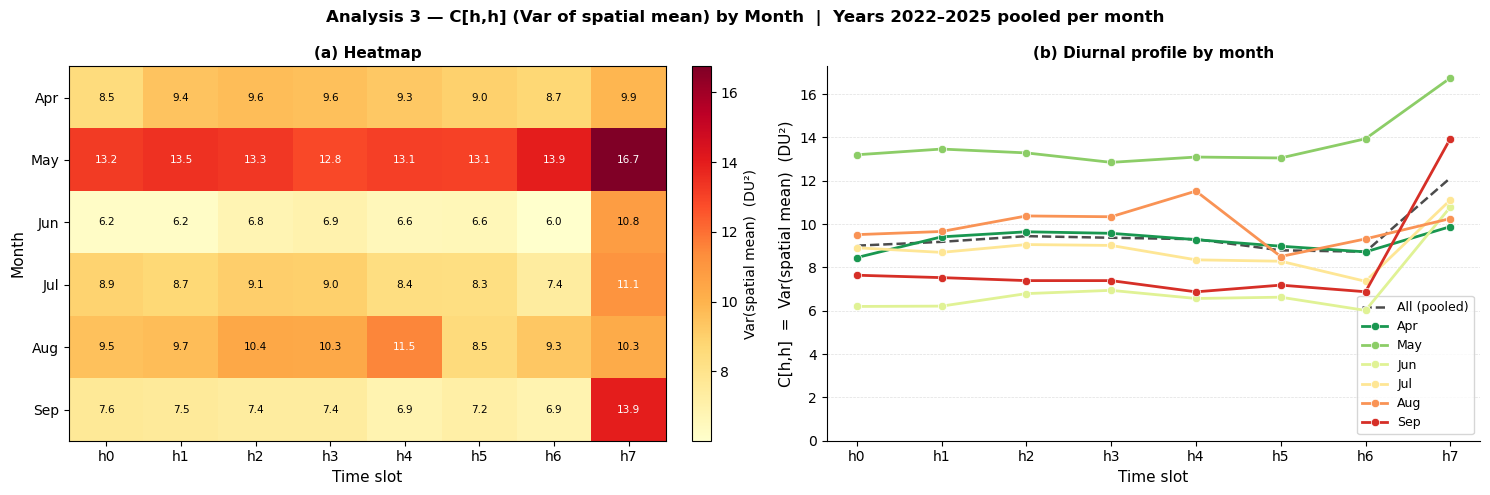

Saved: an3_cov_diag_monthly_no2023.png


In [15]:
# ── Analysis 3: Monthly C[h,h] heatmap + line plot ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f'Analysis 3 — C[h,h] (Var of spatial mean) by Month  |  '
    f'Years {YEARS[0]}–{YEARS[-1]} pooled per month',
    fontsize=12, fontweight='bold'
)

# (a) Heatmap — months only (no All row)
ax = axes[0]
heatmap_data = monthly_cov_diag.drop(index='All')
vals = heatmap_data.values.astype(float)
im = ax.imshow(vals, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=10)
ax.set_yticks(range(len(heatmap_data.index))); ax.set_yticklabels(heatmap_data.index, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('Month', fontsize=11)
ax.set_title('(a) Heatmap', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Var(spatial mean)  (DU²)')
vmax = np.nanmax(vals)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        if np.isfinite(vals[i, j]):
            ax.text(j, i, f'{vals[i,j]:.1f}', ha='center', va='center', fontsize=7.5,
                    color='white' if vals[i, j] > vmax * 0.65 else 'black')

# (b) Line plot: All 기준선 + monthly 전경
ax = axes[1]
all_row = monthly_cov_diag.loc['All'].values.astype(float)

# All: 굵은 검정 점선 기준선 (zorder=2)
ax.plot(range(N_SLOTS), all_row, 'k--',
        lw=1.8, alpha=0.7,
        label='All (pooled)', zorder=2)

# Monthly lines: 전경 (zorder=5+)
for i, mo in enumerate(MONTHS):
    mname = MONTH_NAMES[mo]
    row = monthly_cov_diag.loc[mname].values.astype(float)
    ax.plot(range(N_SLOTS), row, 'o-',
            color=month_colors[i], lw=2.0, ms=6,
            markeredgecolor='white', markeredgewidth=0.5,
            label=mname, zorder=5 + i)

ax.set_xticks(range(N_SLOTS))
ax.set_xticklabels(SLOT_LABELS, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('C[h,h]  =  Var(spatial mean)  (DU²)', fontsize=11)
ax.set_title('(b) Diurnal profile by month', fontsize=11, fontweight='bold')
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, framealpha=0.8, loc='best')

plt.tight_layout()
plt.savefig(OUT_DIR / 'an3_cov_diag_monthly_no2023.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: an3_cov_diag_monthly_no2023.png")

---
## 모델링 판단

### 분석 결과 → 모델 선택 흐름

```
Analysis 1 γ_s(h) 시간대별 차이?  +  Analysis 2 σ_s²(h) 시간대별 차이?
         │                                      │
   둘 다 유의미한 diurnal                  둘 다 일정
         │                                      │
   공간 구조가 diurnal cycle              공간 구조는 time-invariant
         │                                      │
   α(t)·[Z(x,t,d) − μ(x,t)]            β(t,d) + ε(x,t,d)
   (diurnal scaling of spatial field)   (mean만 시간 변동)
```

### Analysis 3과의 연결

- `C[h,h]`가 시간대별로 **일정** → α(t)=const, 즉 scaling이 없어도 됨  
  → `Z(x,t,d) = μ(x,t) + η(x,d) + ε(x,t,d)`  (η: day-specific spatial effect)
- `C[h,h]`가 시간대별로 **달라짐** → 날마다의 변동 크기 자체가 시간대에 따라 다름  
  → `Z(x,t,d) = μ(x,t) + α(t)·η(x,d) + ε(x,t,d)`  (α(t): diurnal amplitude)
- Analysis 1, 2도 함께 커진다면 → α(t)는 공간 구조 전체를 scaling
- Analysis 1, 2가 일정한데 C[h,h]만 다르다면 → overall level만 α(t)로 scaling (spatial pattern은 고정)

### 참고: 3번에 short-lag counterpart가 없는 이유

공간 semivariogram은 lag(거리)를 선택할 수 있어서 lag=1,2,3... 으로 고주파/저주파를 분리할 수 있다.  
반면 temporal semivariogram for spatial mean은 이미 슬롯 단위가 고정(h0..h7)이라  
lag=1은 1슬롯(~1h)으로 고정 — 이게 이미 "short lag"이고, 8×8 행렬의 대각/오프-대각이 그 모든 정보를 담는다.